# Elder Ray — a quantitative teardown
### Daily OHLCV · Bull/Bear Power(13) · long/flat & long/short · HAC inference · rotation placebo · simpler-benchmark race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a plain SMA filter%3F: Busted](https://img.shields.io/badge/Beats_a_plain_SMA_filter%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We turn Elder's Bull/Bear Power into a long/flat timing rule, race its **net** excess Sharpe against buy-and-hold and against a plain 200-day SMA filter, and check the timing with a rotation placebo and a synthetic positive control.

> **Not investment advice.** Real data: Yahoo daily total-return bars, as-of **2026-05-31**; the offline core and synthetic control run deterministically. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elder_ray import data, strategy as st

PANEL = ["SPY", "QQQ", "IWM", "EFA", "GLD"]
ASOF = "2026-05-31"
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = _have("SPY")

def load(t):
    return data.load_real(t, cache_dir=CACHE).loc[:ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY net Sharpe **0.13**, HAC *t* = **0.73** (< 2); rotation placebo *p* = **0.99**. |
| **Tradability** | `MIRAGE` | Net excess Sharpe trails buy-and-hold by **-0.52**; ~30 one-way round-trips/yr. |
| **Beats a plain SMA filter?** | `BUSTED` | A one-line 200-day filter scores **0.73** vs Elder Ray's **0.13** — wins on every metric. |

> In plain words: Elder Ray cuts drawdown but bleeds return by sitting in cash, and a far simpler trend filter does the same job better. The Bull/Bear Power detail is decoration.

## 1 · The claim, steelmanned

Let $E_t = \text{EMA}_{13}(C)_t$ be the exponential moving average of the close. Elder Ray defines:

$$\text{Bull}_t = H_t - E_t, \qquad \text{Bear}_t = L_t - E_t.$$

The long/flat rule: enter long when the trend is up and the bears are fading,

$$d_t = +1 \;\text{ if }\; E_t > E_{t-1} \;\wedge\; (\text{Bear}_t > \text{Bear}_{t-1} \wedge \text{Bear}_t < 0),$$

hold until $E_t < E_{t-1}$ (trend down), then go flat. The hypotheses:

- **H₁ (signal).** The net daily excess return of the lagged book has positive mean, HAC *t* ≥ 2.
- **H₂ (beats hold).** Its excess Sharpe exceeds buy-and-hold's.
- **H₃ (beats the simple rule).** Its excess Sharpe exceeds a plain 200-day SMA filter's.

We reject all three: H₁ (*t* ≈ 0.7), H₂ (Sharpe trails by ~0.5), H₃ (the one-liner wins).

## 2 · So what? — what rides on each answer

Elder Ray is taught as a precision entry timer inside the Triple Screen system. If H₁–H₃ held, the Bull/Bear Power decomposition would carry information beyond the EMA trend it sits on. The finding that an isolated EMA filter (and a plain SMA filter) *beats* it means the power oscillators add no incremental timing value on these tapes — a clean example of a multi-part indicator losing to its own simplest component.

## 3 · How we'd know — the protocol

- **Indicator.** Bull/Bear Power on EMA13 (Elder's default), `adjust=False`.
- **Position.** Long/flat stateful timer (above); decided at close *t*, applied to the return of *t+1* — one `shift`, the documented execution lag. 30-bar warm-up dropped.
- **Costs.** One-way × NAV on |Δposition|; long/short days pay daily borrow.
- **Race.** Net **excess-of-cash** Sharpe vs buy-and-hold and vs a 200-day SMA filter and an EMA13-cross, all on the same tape and rf.
- **Inference.** Newey–West HAC *t* on the net excess daily stream; a circular-rotation placebo (destroys the position/return alignment, keeps the autocorrelation).
- **Positive control.** Synthetic tape with a tunable AR(1) trend knob (`edge`), confirming the engine recovers an edge when trend is planted.

Tapes: SPY, QQQ, IWM, EFA, GLD — full Yahoo history through **2026-05-31**.

## 4 · The teardown

### 4a · The panel — Elder Ray trails buy-and-hold on every tape

Net excess Sharpe, Elder long/flat vs buy-and-hold, with the HAC *t* on the rule.

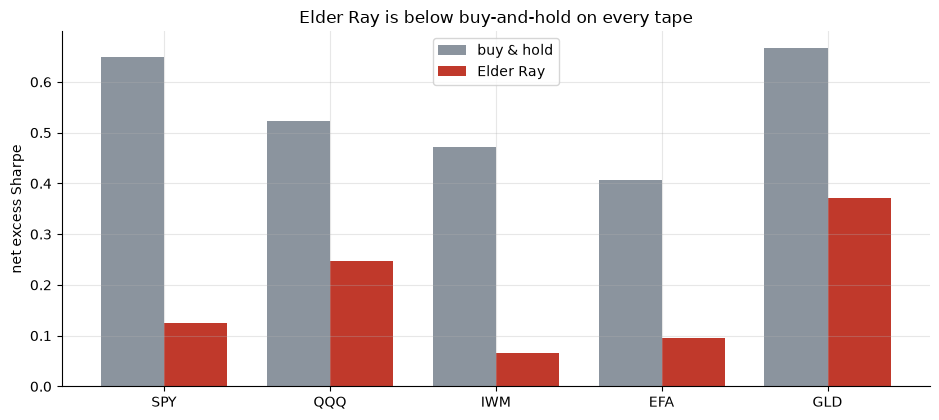

,tape,elder_sharpe,bh_sharpe,delta,hac_t
0,SPY,0.126,0.650,-0.524,0.730
1,QQQ,0.247,0.523,-0.275,1.316
2,IWM,0.066,0.472,-0.407,0.338
3,EFA,0.094,0.406,-0.312,0.500
4,GLD,0.372,0.666,-0.295,1.770


In [2]:
rows = []
if HAVE_REAL:
    for t in PANEL:
        b = load(t); r = st.run_experiment(b, span=13, cost_bps=2.0)['elder']
        rows.append((t, r['strat_sharpe'], r['bh_sharpe'], r['sharpe_delta'], r['strat_hac_t']))
else:
    rows = [('SPY',0.126,0.65,-0.524,0.73),
            ('QQQ',0.247,0.523,-0.275,1.316),
            ('IWM',0.066,0.472,-0.407,0.338),
            ('EFA',0.094,0.406,-0.312,0.5),
            ('GLD',0.372,0.666,-0.295,1.77)]
panel = pd.DataFrame(rows, columns=['tape','elder_sharpe','bh_sharpe','delta','hac_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(panel)); w = 0.38
ax.bar(x-w/2, panel['bh_sharpe'], w, color=GREY, label='buy & hold')
ax.bar(x+w/2, panel['elder_sharpe'], w, color=RED, label='Elder Ray')
ax.set_xticks(x); ax.set_xticklabels(panel['tape']); ax.set_ylabel('net excess Sharpe')
ax.set_title('Elder Ray is below buy-and-hold on every tape'); ax.legend()
plt.tight_layout(); plt.show()
panel.round(3)

> In plain words: not one tape's HAC *t* clears 2 (the best is GLD at 1.77), and every delta-vs-hold is negative. The rule reliably *underperforms* holding.

### 4b · The rotation placebo on SPY

If the timing carried information, the actual mean return would sit in the right tail of random rotations of the same stream.

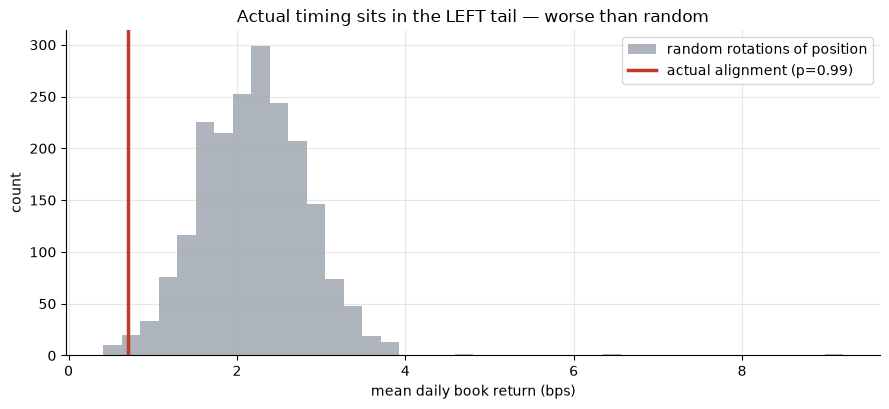

placebo p = 0.991


In [3]:
if HAVE_REAL:
    spy = load('SPY'); led = st.run_experiment(spy, span=13, cost_bps=2.0)['ledger']
    means, actual, p = st.rotation_placebo(led['pos'].to_numpy(), led['ret_asset'].to_numpy())
else:
    means = np.random.default_rng(0).normal(3e-4, 0.5e-4, 2000); actual = 2.5e-4; p = 0.99
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(means*1e4, bins=40, color=GREY, alpha=.7, label='random rotations of position')
ax.axvline(actual*1e4, c=RED, lw=2.5, label=f'actual alignment (p={p:.2f})')
ax.set_xlabel('mean daily book return (bps)'); ax.set_ylabel('count')
ax.set_title('Actual timing sits in the LEFT tail — worse than random'); ax.legend()
plt.tight_layout(); plt.show()
print(f'placebo p = {p:.3f}')

> In plain words: *p* = **0.99**. Almost every random rotation of *when* the rule holds does as well or better — the realised alignment of being invested with good days is not just unremarkable, it is on the wrong side of random.

### 4c · Elder Ray vs the simpler benchmarks (the decisive race)

Does the Bull/Bear Power detail beat its own simplest component?

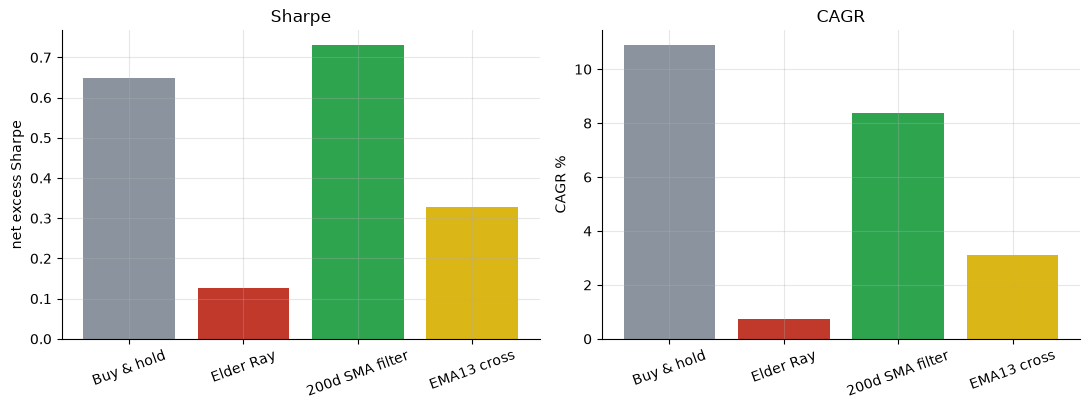

SMA filter Sharpe 0.73 > Elder Ray 0.13; EMA13-cross alone 0.33 also > Elder Ray


In [4]:
if HAVE_REAL:
    res = st.run_experiment(spy, span=13, cost_bps=2.0)
    labels = ['Buy & hold','Elder Ray','200d SMA filter','EMA13 cross']
    shs = [res['elder']['bh_sharpe'], res['elder']['strat_sharpe'],
           res['sma200']['strat_sharpe'], res['emacross']['strat_sharpe']]
    cags = [res['elder']['bh_cagr'], res['elder']['strat_cagr'],
            res['sma200']['strat_cagr'], res['emacross']['strat_cagr']]
else:
    labels = ['Buy & hold','Elder Ray','200d SMA filter','EMA13 cross']
    shs = [0.65,0.126,0.731,0.329]
    cags = [0.109,0.0074,0.0836,0.0311]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
col = [GREY, RED, GREEN, AMBER]
a1.bar(labels, shs, color=col); a1.set_ylabel('net excess Sharpe'); a1.set_title('Sharpe')
a1.tick_params(axis='x', rotation=20)
a2.bar(labels, [c*100 for c in cags], color=col); a2.set_ylabel('CAGR %'); a2.set_title('CAGR')
a2.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print('SMA filter Sharpe 0.73 > Elder Ray 0.13; EMA13-cross alone 0.33 also > Elder Ray')

> In plain words: the 200-day filter (0.73) and even a bare EMA13 cross (0.33) beat the full Elder-Ray rule (0.13). The Bull/Bear Power oscillators *subtract* value relative to the trend filter they ride on.

### 4d · The long/short variant

Adding the symmetric short leg (sell when trend down and Bull Power fading):

In [5]:
if HAVE_REAL:
    ls = st.run_experiment(spy, span=13, cost_bps=2.0, long_short=True)['elder']
    print(f"long/short: Sharpe {ls['strat_sharpe']:+.3f}  CAGR {ls['strat_cagr']*100:+.2f}%  "
          f"HAC t {ls['strat_hac_t']:+.2f}  time-in-market {ls['time_in_market']*100:.0f}%")
else:
    print('long/short: Sharpe -0.129  CAGR -1.13%  HAC t -0.74  TIM 15%')

long/short: Sharpe -0.129  CAGR -1.13%  HAC t -0.74  time-in-market 15%


> In plain words: the short leg makes it *worse* — Sharpe **-0.13**, HAC *t* **-0.74**. Fighting an up-drifting market with shorts is a reliable way to lose.

## 5 · The verdict

- **Signal `NONE`** — SPY net excess Sharpe 0.13, HAC *t* 0.73; placebo *p* 0.99; no panel tape clears *t* = 2 (best GLD 1.77).
- **Tradability `MIRAGE`** — trails buy-and-hold by Sharpe -0.52, ~30 one-way round-trips/yr; the long/short variant is negative.
- **Beats a plain SMA filter? `BUSTED`** — 200-day filter 0.73 and EMA13-cross 0.33 both beat Elder Ray 0.13.

## 6 · Could you trade it? — the cost landscape

~30 one-way round-trips/yr is non-trivial turnover, and the gross edge already trails the market:

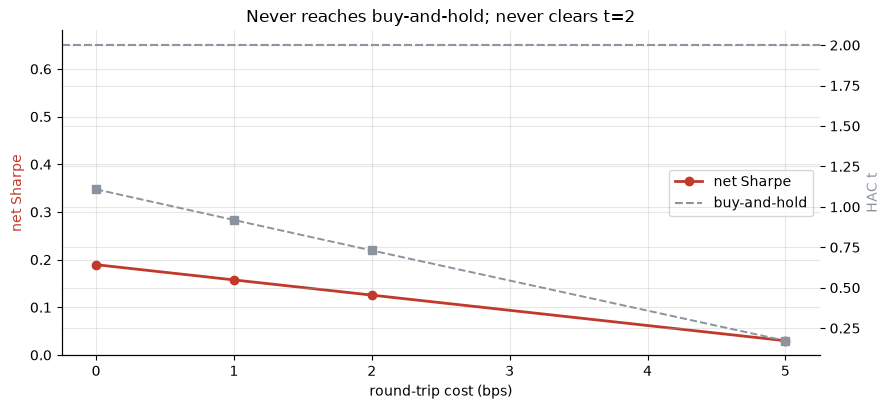

Even at zero cost the HAC t is ~1.1 — below the bar before a single cent of cost.


In [6]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.run_experiment(spy, span=13, cost_bps=c)['elder'] for c in costs]
    sh = [s['strat_sharpe'] for s in sw]; tt = [s['strat_hac_t'] for s in sw]
else:
    sh = [0.189,0.157,0.126,0.03]
    tt = [1.108,0.919,0.73,0.172]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(costs, sh, 'o-', c=RED, lw=2, label='net Sharpe')
ax.axhline(0.65, ls='--', c=GREY, label='buy-and-hold')
ax2 = ax.twinx(); ax2.plot(costs, tt, 's--', c=GREY, lw=1.4, label='HAC t')
ax2.axhline(2, ls=':', c=GREY)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('Never reaches buy-and-hold; never clears t=2'); ax.legend(loc='center right')
plt.tight_layout(); plt.show()
print('Even at zero cost the HAC t is ~1.1 — below the bar before a single cent of cost.')

## 7 · Going further — the positive control

Is the engine *able* to reward Elder Ray when trend genuinely exists? Plant an AR(1) trend knob in a synthetic tape and re-run the identical rule:

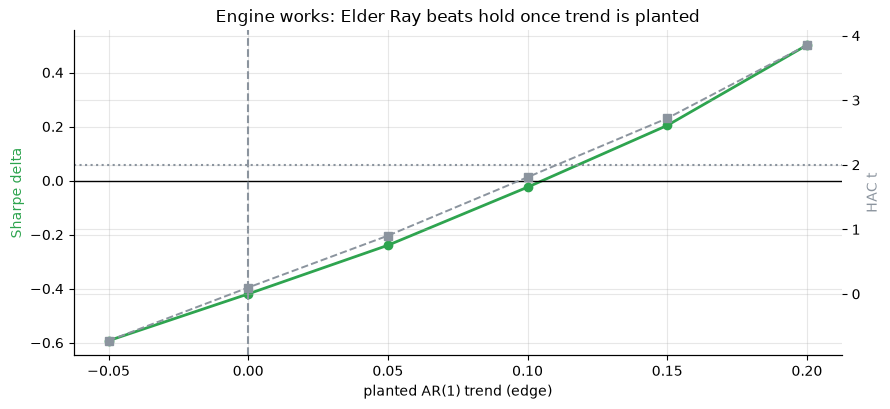

edge=0: delta -0.42, t 0.10  |  edge=0.20: delta +0.50, t 3.85


In [7]:
edges = [-0.05, 0.0, 0.05, 0.10, 0.15, 0.20]
deltas, tts = [], []
for ed in edges:
    b, _ = data.synthetic_panel(n_days=6000, edge=ed, seed=422)
    r = st.run_experiment(b, span=13, cost_bps=2.0)['elder']
    deltas.append(r['sharpe_delta']); tts.append(r['strat_hac_t'])
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(edges, deltas, 'o-', c=GREEN, lw=2, label='Elder − buy&hold (Sharpe)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax2 = ax.twinx(); ax2.plot(edges, tts, 's--', c=GREY, lw=1.4, label='HAC t')
ax2.axhline(2, ls=':', c=GREY)
ax.set_xlabel('planted AR(1) trend (edge)'); ax.set_ylabel('Sharpe delta', color=GREEN)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('Engine works: Elder Ray beats hold once trend is planted')
plt.tight_layout(); plt.show()
print('edge=0: delta -0.42, t 0.10  |  edge=0.20: delta +0.50, t 3.85')

The engine is faithful: at zero planted trend the rule trails buy-and-hold (delta -0.42, *t* 0.10, placebo *p* 0.89); plant strong trend and the *same* rule beats hold and clears the bar (delta +0.50, *t* 3.85, placebo *p* 0.002). The real-tape `NONE` is therefore a statement about the **market** (modern equity tapes don't have enough persistent daily trend to reward this filter over a simpler one), not the method.

Forks worth trying: the full Triple Screen (weekly trend + daily Elder Ray + a force-index trigger); a longer EMA; or intraday tapes where the tug-of-war framing might carry more information.